# <center>Breast Cancer Diagnosis </center>

The main focus of this project is data visualization and breast cancer diagnosis using regression techniques and machine learning. This dataset is designed for binary classification tasks to predict whether a breast tumor is benign (non-cancerous) or malignant (cancerous), to aid in early and accurate breast cancer detection.

In [1]:
# Import Needed Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, label_binarize, LabelBinarizer
from pathlib import Path

#CSV File Path
data_path = Path('C:/Users/ajbre/Documents/Jupyter Projects/Datasets/Breast_cancer_dataset.csv')

print(f"Data File Path: {data_path}")

Data File Path: C:\Users\ajbre\Documents\Jupyter Projects\Datasets\Breast_cancer_dataset.csv


In [2]:
# Load Breast Cancer Data
df = pd.read_csv(data_path)

In [3]:
# Basic Data Info
print(f"\n Rows, Cols: {df.shape}")


 Rows, Cols: (569, 33)


In [5]:
display(df.head())
df.info()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Key Column:**
* Diagnosis: The target variable, labeled as:
    * M (Malignant): Indicates a cancerous tumor.
    * B (Benign): Indicates a non-cancerous tumor.
    
**Additional Columns:**
* Features: (30 columns) Numerical measurements of cell nuclei, such as radius, texture, perimeter, and area.
* The 30 Features are grouped into 3 main categories
    * Mean: Average values of measurements
    * Standar Error (SE): Variability of measurements
    * Worst: Largest (worst) values of measurements
* Each Category includes 10 specific measurements:
    1. Radius (mean of distances from center to points on the perimeter)
    2. Texture (standard deviation of grayscale values)
    3. Perimeter
    4. Area
    5. Smoothness (local variation in radius lengths)
    6. Compactness (perimeter² / area - 1.0)
    7. Concavity (severity of concave portions of the contour)
    8. Concave points (number of concave portions of the contour)
    9. Symmetry
    10. Fractal dimension ("coastline approximation" - 1)

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df['Unnamed: 32']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
564   NaN
565   NaN
566   NaN
567   NaN
568   NaN
Name: Unnamed: 32, Length: 569, dtype: float64

In [8]:
df['id']

0        842302
1        842517
2      84300903
3      84348301
4      84358402
         ...   
564      926424
565      926682
566      926954
567      927241
568       92751
Name: id, Length: 569, dtype: int64

Dropping the 'Unnamed 32' column filled with NaN, as well as the 'id' column, which is of no use for diagnosis.

In [9]:
df.drop(columns = ['Unnamed: 32'], inplace = True)
df.drop(columns = ['id'], inplace = True)

In [10]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [11]:
#Descriptive statistics for this dataset
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [13]:
df['diagnosis'].value_counts()

B    357
M    212
Name: diagnosis, dtype: int64

**This is what we are really interested in with this dataset. Predicting breast cancer using the diagnosis column.**
- M (Malignant): Indicates a cancerous tumor.
- B (Benign): Indicates a non-cancerous tumor.

From the value counts above, this dataset offers a relatively balanced distribution for training robust models.

### Exploratory Data Analysis/Visualization

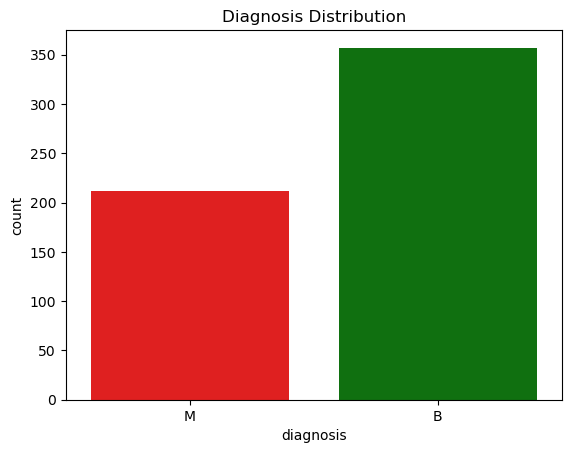

In [12]:
sns.countplot(data = df, x = 'diagnosis', palette = ['red', 'green'])
plt.title('Diagnosis Distribution')
plt.show()

Most machine learning models can only work with numerical values. Such as K-Nearest Neighbors, which calculates the Euclidean distance between the two observations of a feature. Therefore, it is necessary to transform the categorical values of the relevant features into numerical ones for proper data ingestion. As such we have to convert the 'Diagnosis' column into numerical values, with 0 = Benign and 1 = Malignant.

In [14]:
#Label Encoding 'Diagnosis' column
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [15]:
df['diagnosis']

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [16]:
df['diagnosis'].value_counts()

0    357
1    212
Name: diagnosis, dtype: int64

- 0 (Benign): Indicates a non-cancerous tumor.
- 1 (Malignant): Indicates a cancerous tumor.

The value counts remain the same, just the data type changes.

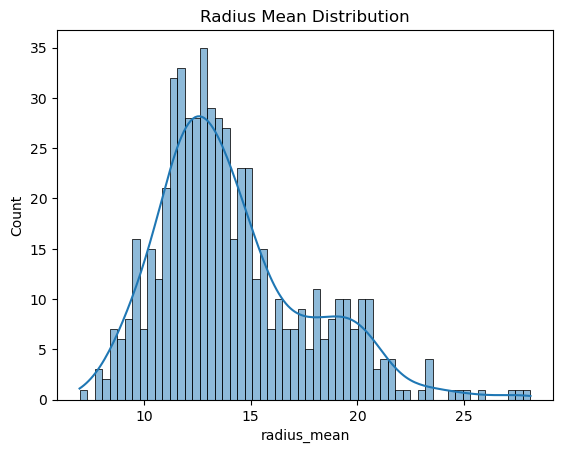

In [17]:
sns.histplot(df['radius_mean'], kde = True, bins = 60)
plt.title('Radius Mean Distribution')
plt.show()

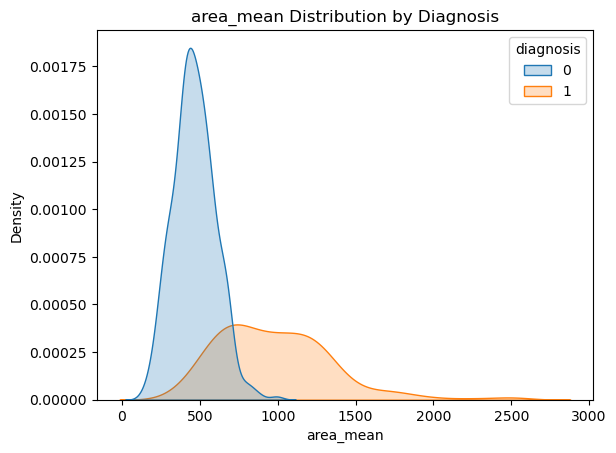

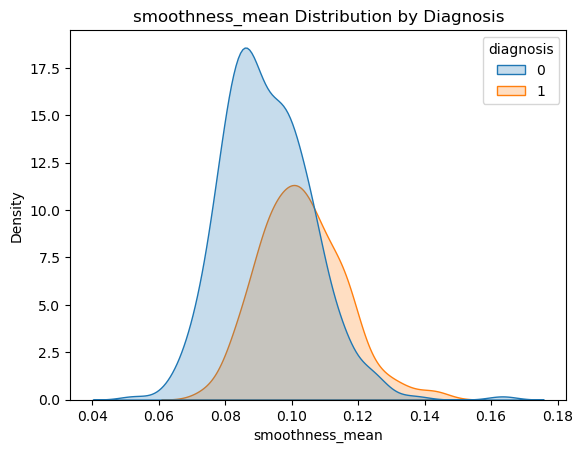

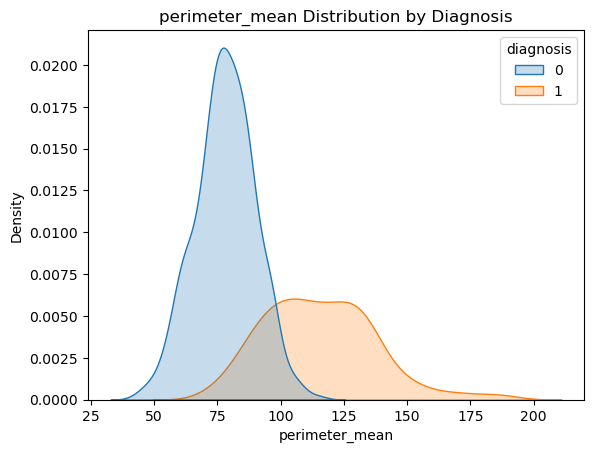

In [18]:
for col in ['area_mean', 'smoothness_mean', 'perimeter_mean']:
    sns.kdeplot(data = df, x = col, hue = 'diagnosis', fill = True)
    plt.title(f'{col} Distribution by Diagnosis')
    plt.show()

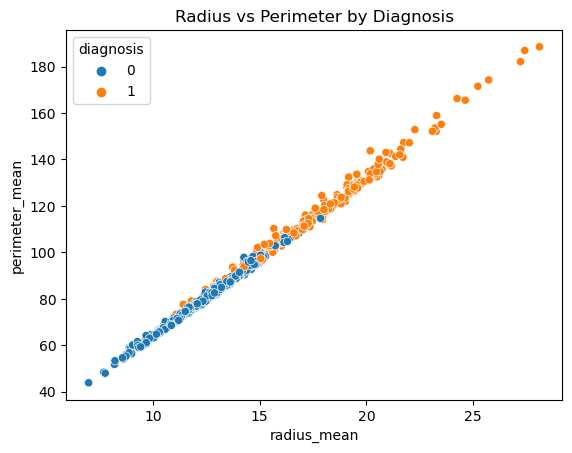

In [19]:
sns.scatterplot(x = 'radius_mean', y = 'perimeter_mean', hue = 'diagnosis', data = df)
plt.title('Radius vs Perimeter by Diagnosis')
plt.show()

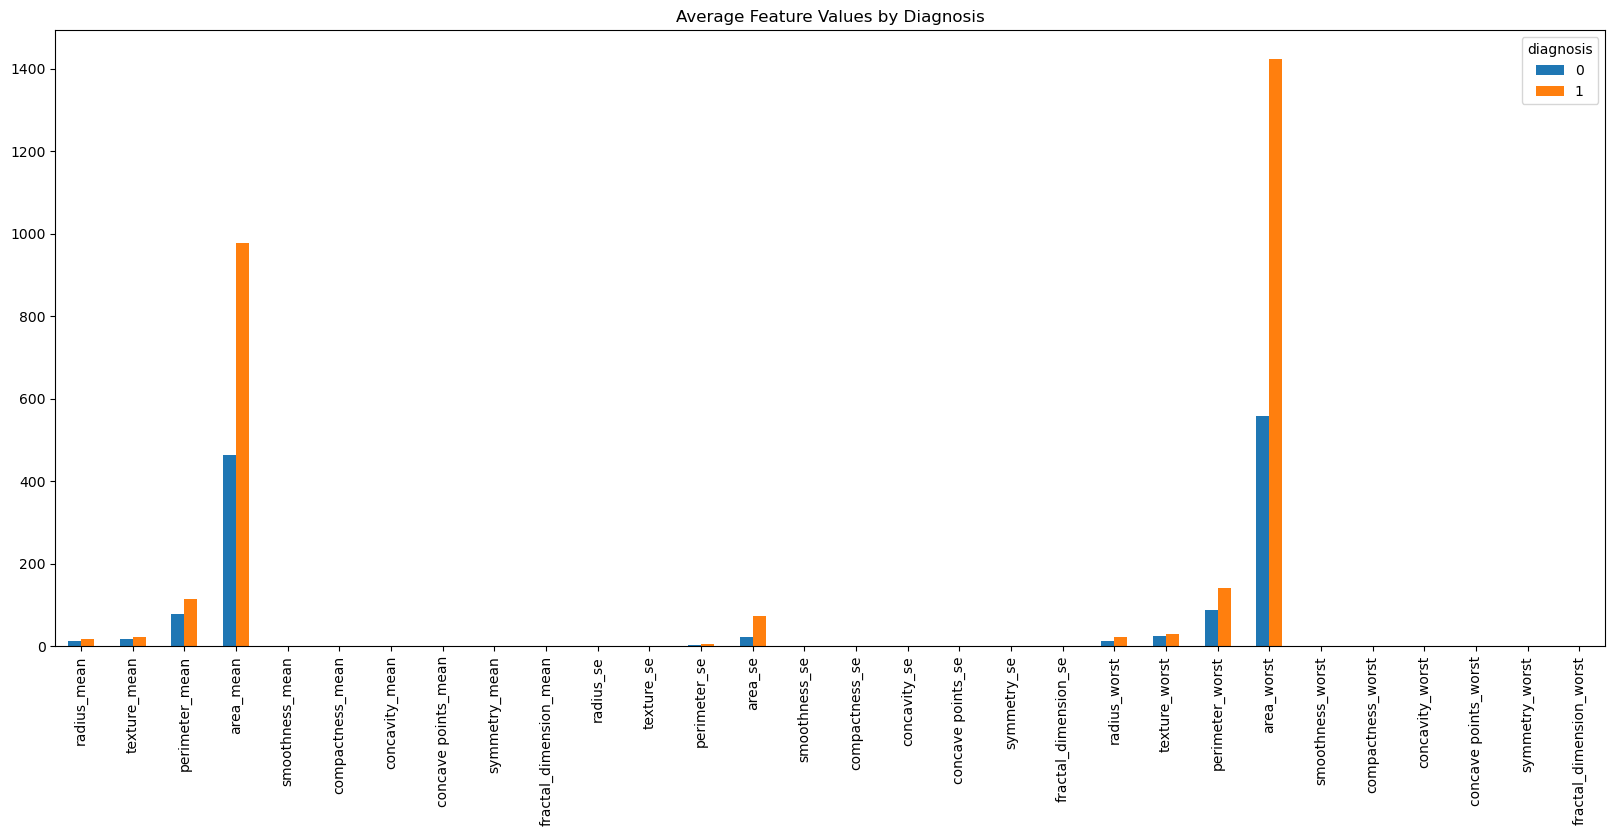

In [20]:
df.groupby('diagnosis').mean().T.plot(kind = 'bar', figsize = (20,8))
plt.title('Average Feature Values by Diagnosis')
plt.xticks(rotation = 90)
plt.show()

The Pearson correlation coefficient, which is a measure of the linear association between two variables, has a value between -1 and 1 where:

* -1 indicates a perfectly negative linear correlation between two variables
* 0 indicates no linear correlation between two variables
* 1 indicates a perfectly positive linear correlation between two variables


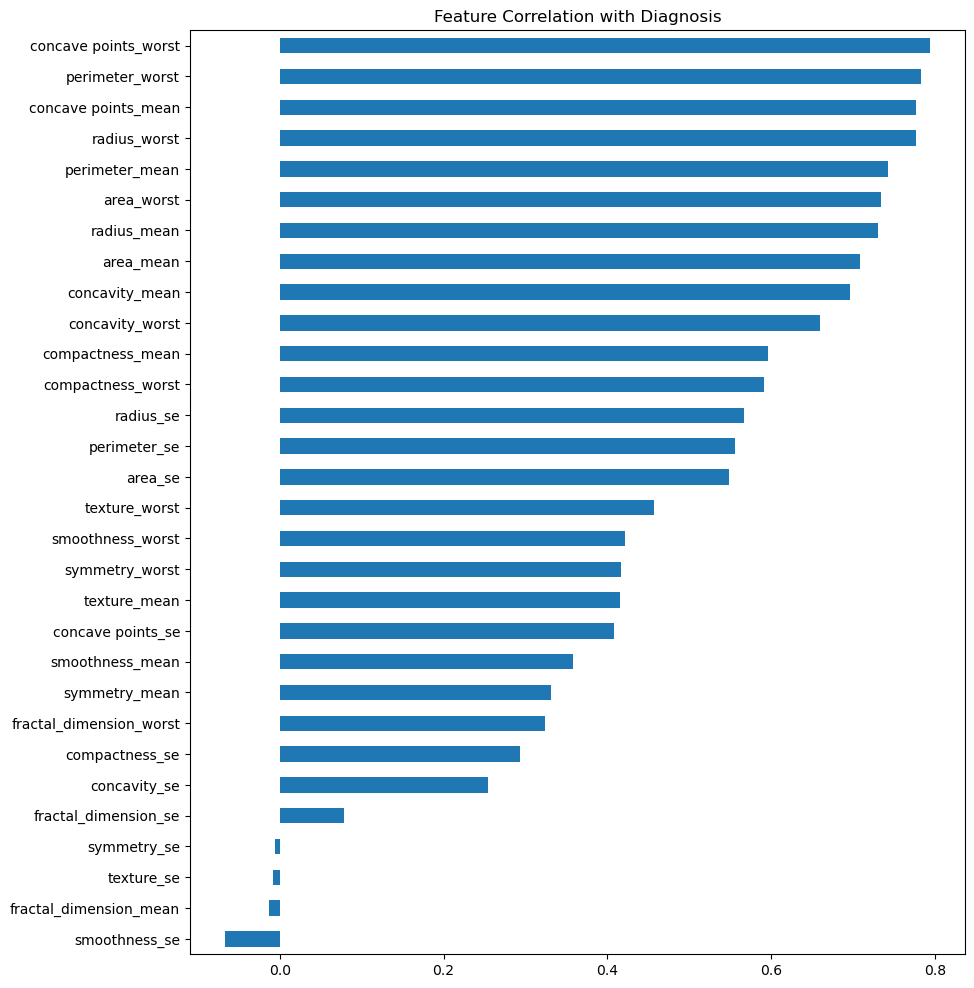

In [21]:
#Correlation with Diagnosis bar plot
corr_diag = df.corr()['diagnosis'].drop('diagnosis').sort_values()
corr_diag.plot(kind = 'barh', figsize = (10,12))
plt.title('Feature Correlation with Diagnosis')
plt.show()

### Model Selection

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [39]:
# Creating an X (features) and y (diagnosis) dataframes
X = df.drop('diagnosis', axis = 1)
y = df['diagnosis']

In [26]:
# Creating the train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
# These are the models we will be using to diagnosis breast cancer
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "Gaussian Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder = False, eval_metric = 'logloss'),
    "LightGBM": LGBMClassifier()
}

In [57]:
# Empty dictionary for model results
results = {}

In [58]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    conf_mat = confusion_matrix(y_test, y_pred)
    class_rpt = classification_report(y_test, y_pred)
    results[name] = acc
    
    print(f"\n🔹Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", conf_mat)
    print("Classification Report:\n", class_rpt)
    
print("\n📊Accuracy Summary:")
for name, acc in results.items():
    print(f"{name:25}: {acc:.4f}")


🔹Model: Logistic Regression
Accuracy: 0.9737
Confusion Matrix:
 [[70  1]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


🔹Model: K-Nearest Neighbors
Accuracy: 0.9474
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


🔹Model: Decision Tree
Accuracy: 0.9386
Confusion Matrix:
 [[68  3]
 [ 4 39]]
Classification Report:
               precision    r

In [59]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [60]:
cvk = StratifiedGroupKFold(n_splits = 5, shuffle = True, random_state = 42)

In [61]:
cv_scores = {}
roc_auc_scores = {}


✨Model: Logistic Regression
Test Accuracy: 0.9737
Cross-Validation Accuracy: 0.9736
AUC Score: 0.9974


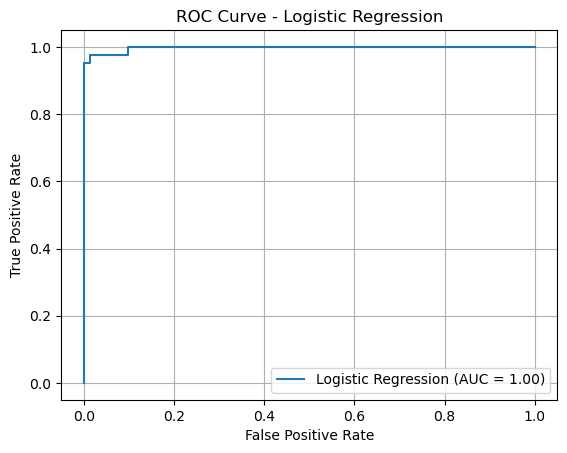

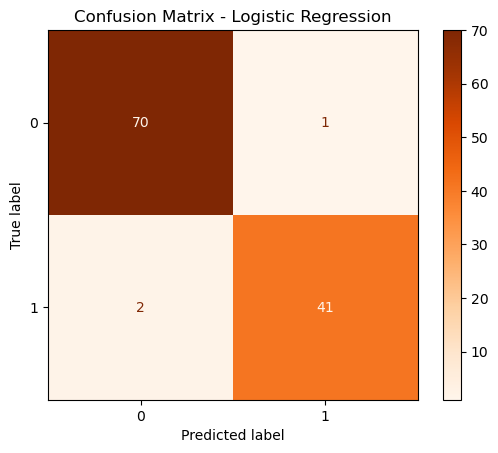


✨Model: K-Nearest Neighbors
Test Accuracy: 0.9474
Cross-Validation Accuracy: 0.9604
AUC Score: 0.9820


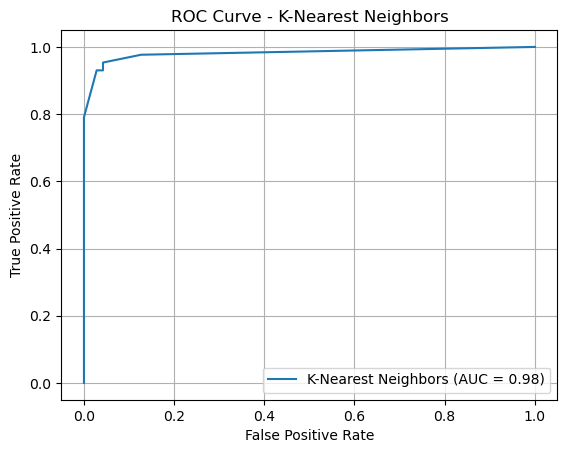

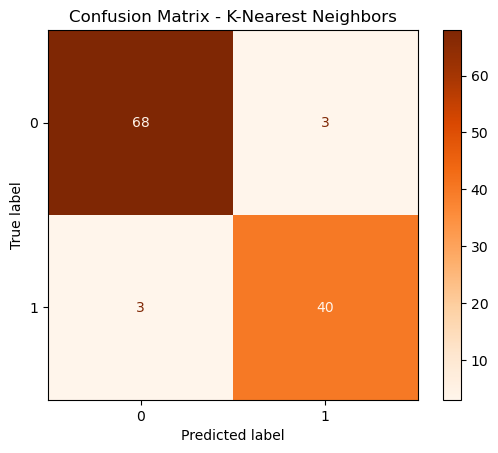


✨Model: Decision Tree
Test Accuracy: 0.9211
Cross-Validation Accuracy: 0.9143
AUC Score: 0.9183


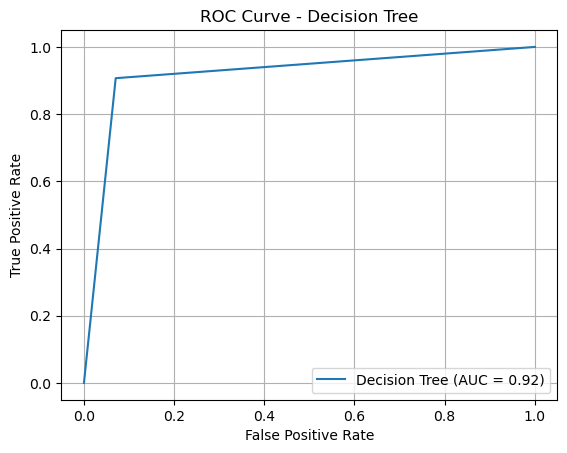

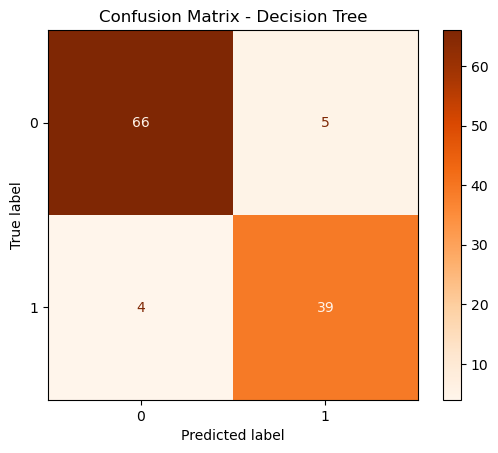


✨Model: Random Forest
Test Accuracy: 0.9649
Cross-Validation Accuracy: 0.9582
AUC Score: 0.9964


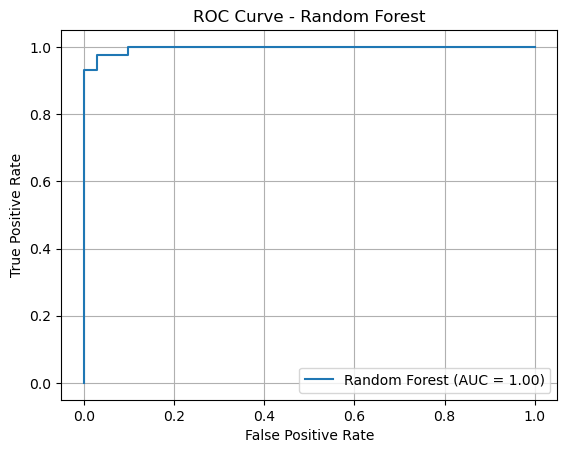

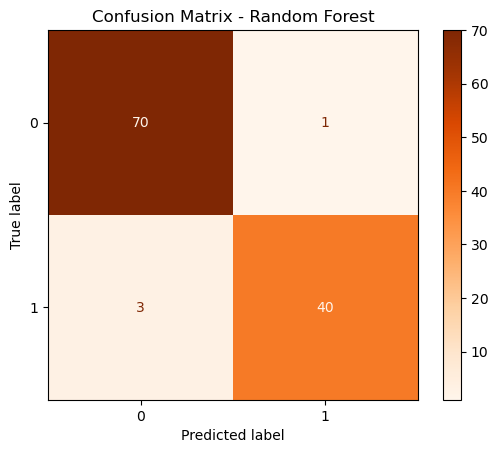


✨Model: Support Vector Machine
Test Accuracy: 0.9825
Cross-Validation Accuracy: 0.9758
AUC Score: 0.9974


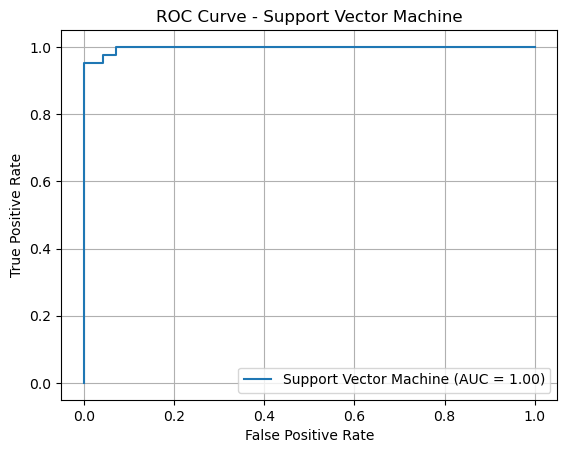

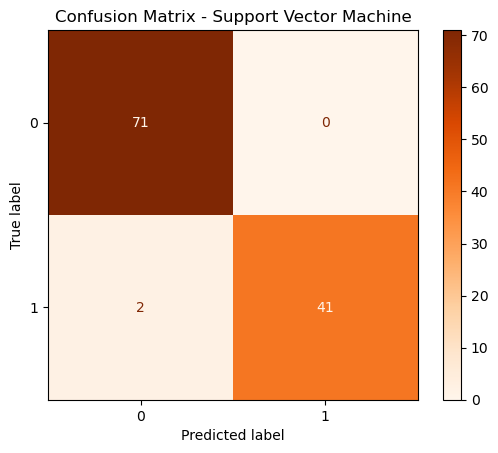


✨Model: Gaussian Naive Bayes
Test Accuracy: 0.9649
Cross-Validation Accuracy: 0.9341
AUC Score: 0.9974


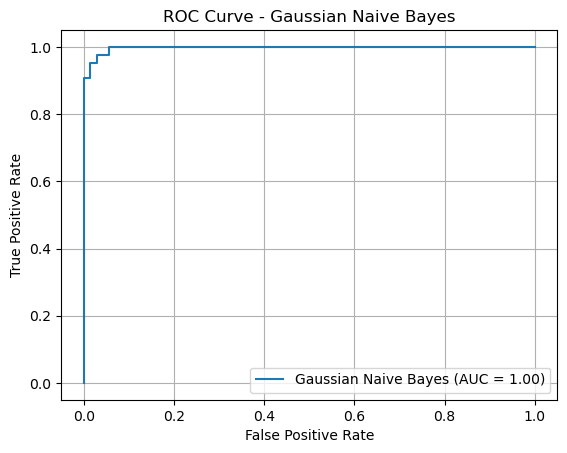

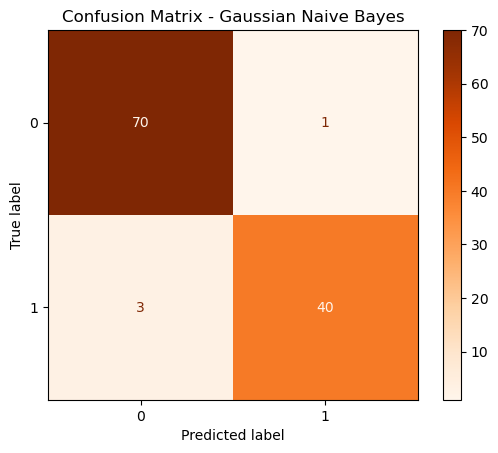


✨Model: Gradient Boosting
Test Accuracy: 0.9561
Cross-Validation Accuracy: 0.9538
AUC Score: 0.9951


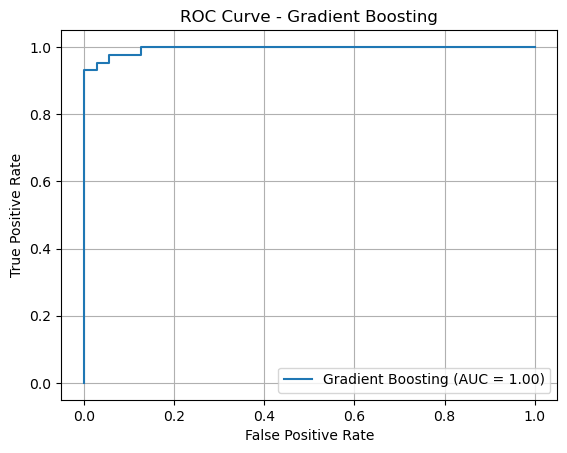

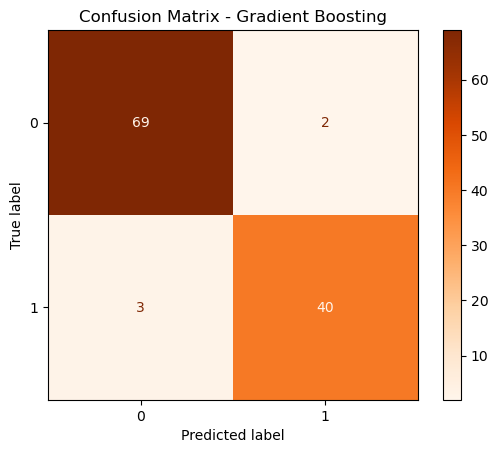


✨Model: AdaBoost
Test Accuracy: 0.9737
Cross-Validation Accuracy: 0.9648
AUC Score: 0.9971


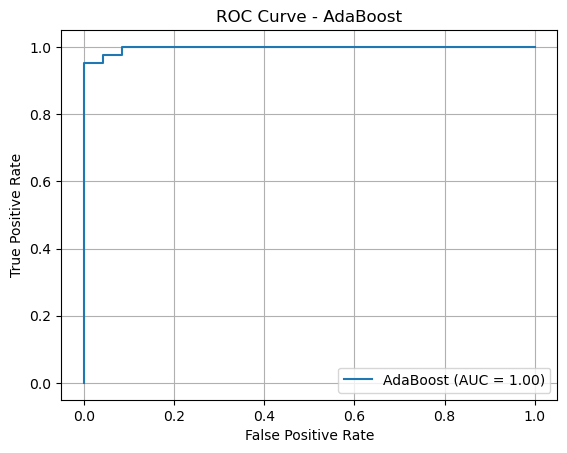

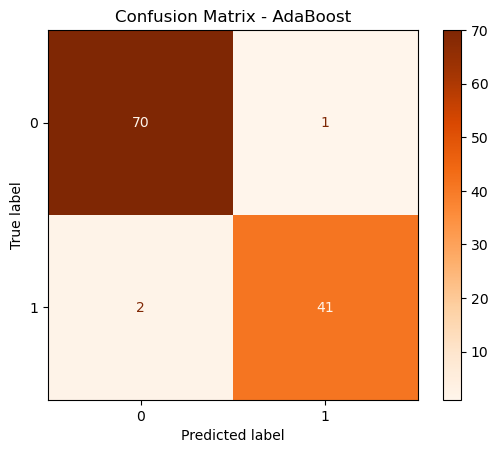


✨Model: XGBoost
Test Accuracy: 0.9561
Cross-Validation Accuracy: 0.9626
AUC Score: 0.9908


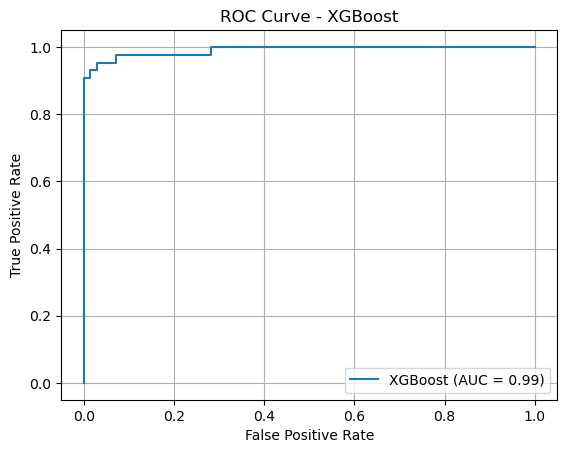

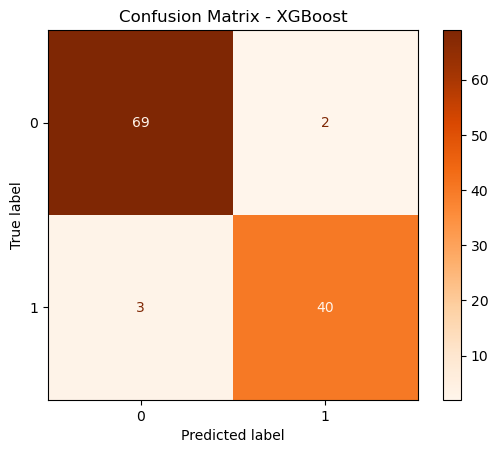


✨Model: LightGBM
Test Accuracy: 0.9649
Cross-Validation Accuracy: 0.9604
AUC Score: 0.9951


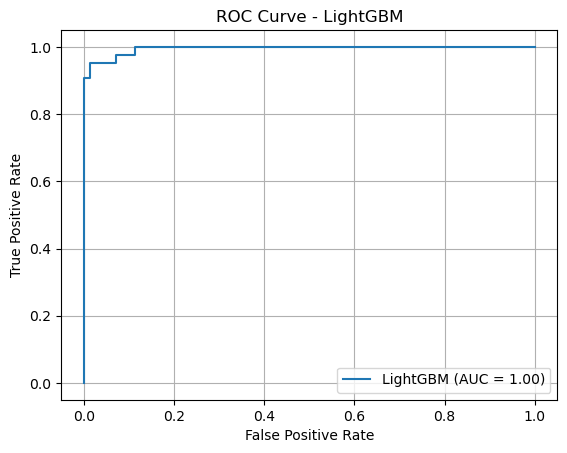

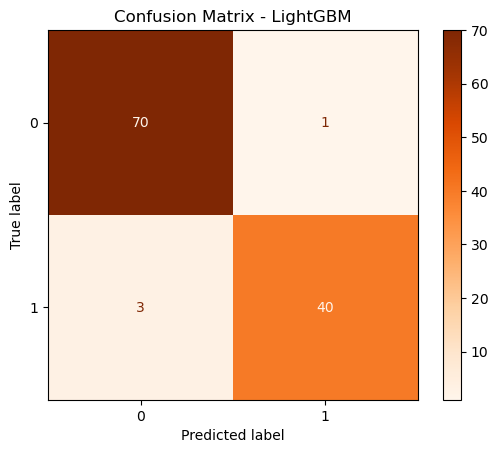

In [62]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv = 5, scoring = 'accuracy').mean()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    cv_scores[name] = cv_acc
    roc_auc_scores[name] = roc_auc
    
    print(f"\n✨Model: {name}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Cross-Validation Accuracy: {cv_acc:.4f}")
    print(f"AUC Score: {roc_auc:.4f}")
    
    RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = name).plot()
    plt.title(f'ROC Curve - {name}')
    plt.grid(True)
    plt.show()
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)
    disp.plot(cmap = 'Oranges')
    plt.title(f'Confusion Matrix - {name}')
    plt.grid(False)
    plt.show()

ROC Curve and AUC evaluate the quality of the prediction classifier. ROC shows the comparison between True Positive Rate and False Positive Rate across all thresholds. An AUC value closer to 1.0 means better performance. This is especially important if you have Class Imbalance. 

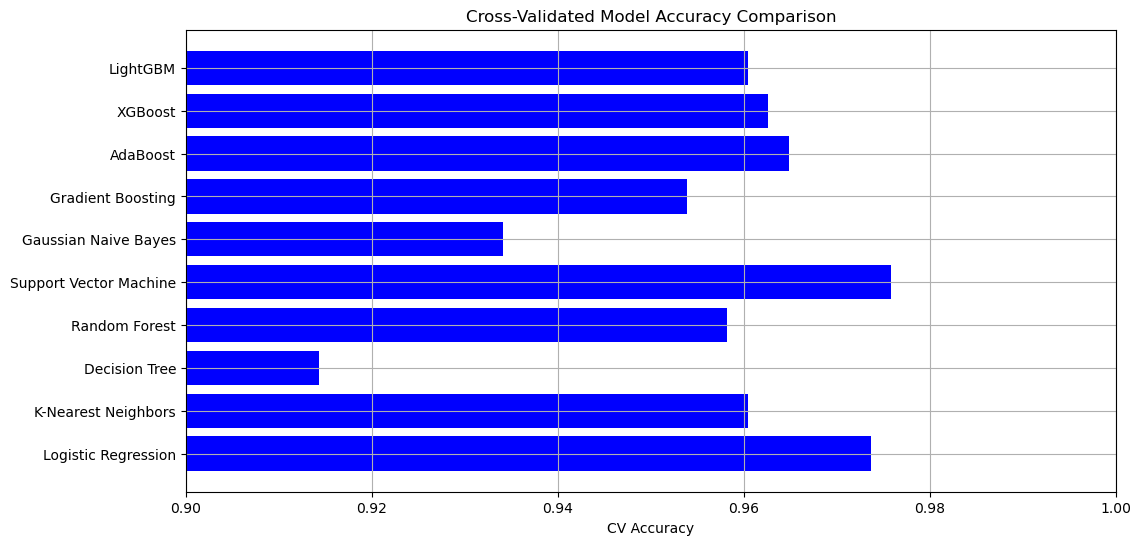

In [63]:
# Models Accuracy Comparison
plt.figure(figsize=(12,6))
plt.barh(list(cv_scores.keys()), list(cv_scores.values()), color = 'blue')
plt.title('Cross-Validated Model Accuracy Comparison')
plt.xlabel('CV Accuracy')
plt.grid(True)
plt.xlim(0.9, 1.0)
plt.show()

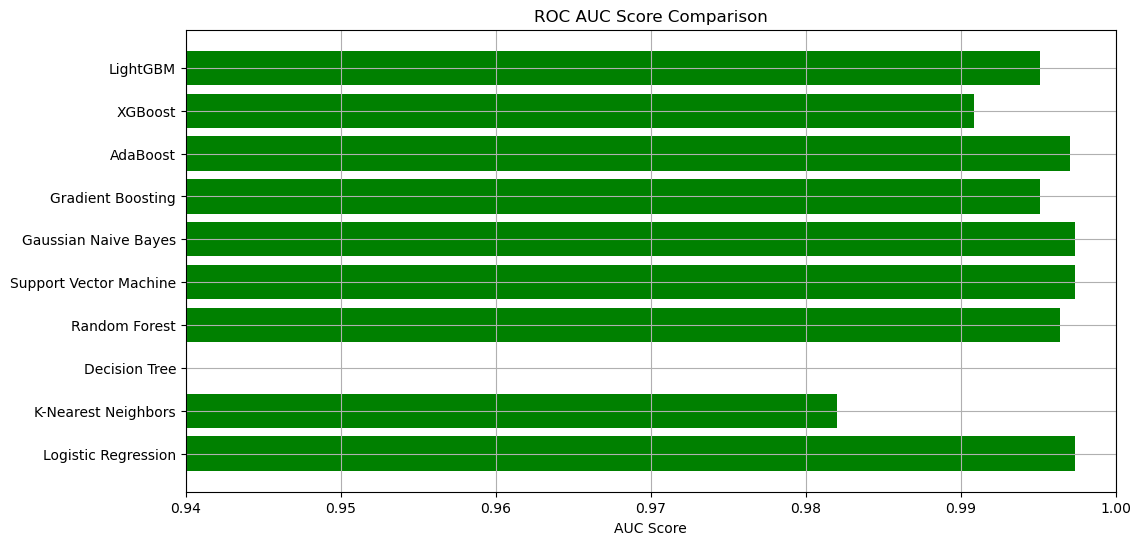

In [64]:
# Models ROC-AUC Score Comparison
plt.figure(figsize=(12,6))
plt.barh(list(roc_auc_scores.keys()), list(roc_auc_scores.values()), color = 'green')
plt.title('ROC AUC Score Comparison')
plt.xlabel('AUC Score')
plt.grid(True)
plt.xlim(0.94, 1.0)
plt.show()

### Best Models

In [65]:
best_auc_model = max(roc_auc_scores, key = roc_auc_scores.get)
best_cv_model = max(cv_scores, key = cv_scores.get)
print(f"\n🎖️ Best AUC Model: {best_auc_model} - AUC: {roc_auc_scores[best_auc_model]:.4f}")
print(f"🎖️ Best Cross-Validated Model: {best_cv_model} - CV Acccuracy: {cv_scores[best_cv_model]:.4f}")


🎖️ Best AUC Model: Logistic Regression - AUC: 0.9974
🎖️ Best Cross-Validated Model: Support Vector Machine - CV Acccuracy: 0.9758


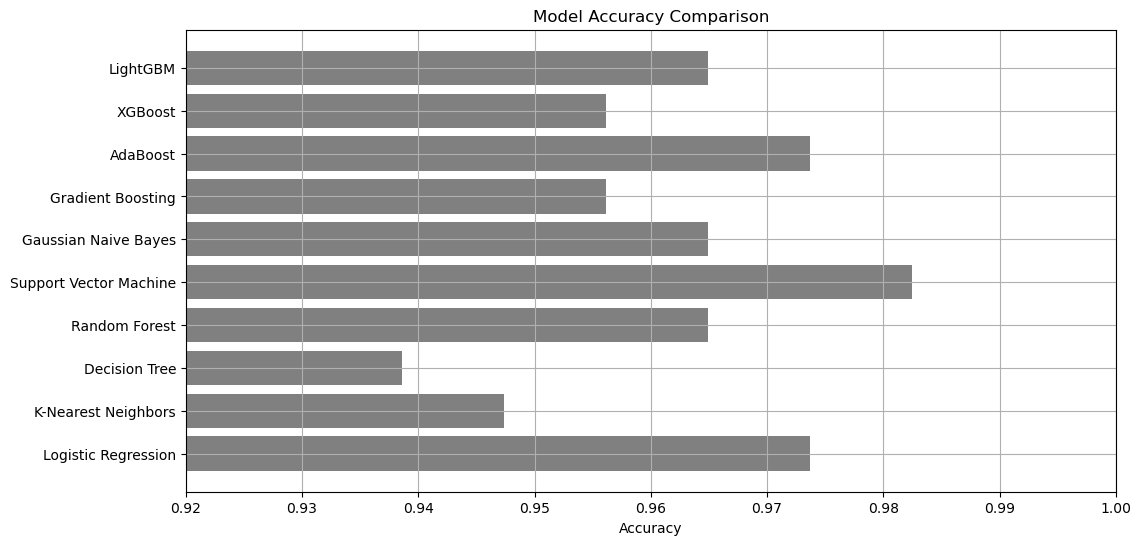

In [66]:
plt.figure(figsize=(12,6))
plt.barh(list(results.keys()), list(results.values()), color = 'grey')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(.92, 1.0)
plt.grid(True)
plt.show()

In [67]:
best_model = max(results, key = results.get)
print(f"\n🏆 Best Performing Model: {best_model} with Accuracy = {results[best_model]:.4f}")


🏆 Best Performing Model: Support Vector Machine with Accuracy = 0.9825


It seems that the **Support Vector Machine model** is the best with an accuracy of **.9825**. Click the link to learn more about the SVM model, https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/

* Future Considerations:
    * Hyper-parameter tuning
    * Principal Component Analysis (PCA) reducing dimensionality of the dataset
    * Web app